# Train rPPG Branch v3 — DeepPhysCAN v2 (Stronger Architecture)

**Cải tiến so với v2:**
- Kiến trúc lớn hơn: 4 ResConvBlocks (48→96→192→256) + SE + Residual (~3.8M params)
- Temporal Transformer (2 layers, 4 heads) thay cho TemporalAttentionPool
- `CAN_IMG_SIZE = 96` (thay vì 72) — giữ nhiều thông tin pixel hơn
- `DIFF_EPS = 0.01` (thay vì 1.0) — bảo toàn tín hiệu rPPG yếu
- `CLIP_LEN_TRAIN = 48` — nhiều temporal context hơn
- Gradient accumulation + chunk processing tránh OOM


In [1]:
!pip install -q timm


In [2]:
import os, glob, time, random, copy, json, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN ====================
CACHE_DIR      = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
MANIFEST_CSV   = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX     = "/kaggle/working/ffpp_c23_rppg_cache"

assert os.path.isdir(CACHE_DIR), f"Không tìm thấy CACHE_DIR: {CACHE_DIR}"

# ==================== THAM SỐ (v3 — cải tiến) ====================
CAN_IMG_SIZE     = 96        # v2=72 → v3=96: giữ nhiều thông tin pixel
CLIP_LEN_TRAIN   = 48        # v2=32 → v3=48: nhiều temporal context
CLIP_LEN_EVAL    = 96        # v2=64 → v3=96: dài hơn khi eval
MIN_FRAMES       = 50

BATCH_SIZE       = 8         # giảm vì ảnh lớn hơn + model nặng hơn
GRAD_ACCUM       = 2         # effective batch = 8 × 2 = 16
EPOCHS           = 60
WARMUP_EPOCHS    = 3
LR               = 1.5e-4   # nhỏ hơn v2 vì model lớn hơn
WEIGHT_DECAY     = 1e-2
DROPOUT          = 0.3

MIXUP_ALPHA      = 0.3      # v2=0.2 → v3=0.3: regularize mạnh hơn
LABEL_SMOOTH_EPS = 0.08     # v2=0.05 → v3=0.08
EMA_DECAY        = 0.999
DIFF_EPS         = 0.01     # v2=1.0 → v3=0.01: QUAN TRỌNG — bảo toàn tín hiệu yếu

PATIENCE   = 14
SEED       = 42
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR    = "/kaggle/working/rppg_can_branch"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Cache:", CACHE_DIR)
print(f"CAN_IMG_SIZE={CAN_IMG_SIZE}, CLIP_LEN_TRAIN={CLIP_LEN_TRAIN}, DIFF_EPS={DIFF_EPS}")
print(f"BATCH_SIZE={BATCH_SIZE} × GRAD_ACCUM={GRAD_ACCUM} = effective {BATCH_SIZE*GRAD_ACCUM}")


Device: cuda
Cache: /kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache
CAN_IMG_SIZE=96, CLIP_LEN_TRAIN=48, DIFF_EPS=0.01
BATCH_SIZE=8 × GRAD_ACCUM=2 = effective 16


In [3]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest["out_dir"] = manifest["out_dir"].str.replace(OLD_PREFIX, CACHE_DIR, regex=False)

manifest_ok = manifest[
    manifest["status"].isin(["ok", "skip_exists", "partial"]) & (manifest["n_frames"] >= MIN_FRAMES)
].reset_index(drop=True)

print(f"Video đủ điều kiện: {len(manifest_ok)} / {len(manifest)}")
print(f"n_frames range: {manifest_ok['n_frames'].min()} — {manifest_ok['n_frames'].max()}")
print(manifest_ok.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"}))

train_df = manifest_ok[manifest_ok.split == "train"].reset_index(drop=True)
val_df   = manifest_ok[manifest_ok.split == "val"].reset_index(drop=True)
test_df  = manifest_ok[manifest_ok.split == "test"].reset_index(drop=True)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Video đủ điều kiện: 5000 / 5000
n_frames range: 230 — 240
label  real  fake
split            
test    140   560
train   720  2880
val     140   560

Train: 3600 | Val: 700 | Test: 700


In [4]:
def load_and_resize(path, size=CAN_IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size)).astype(np.float32)


def compute_normalized_diff(curr, prev, eps=DIFF_EPS):
    # Normalize cả 2 về [0,1] trước khi tính diff → eps=0.01 có ý nghĩa
    c = curr / 255.0
    p = prev / 255.0
    return (c - p) / (c + p + eps)


class CANTrainDataset(Dataset):
    def __init__(self, df, clip_len=CLIP_LEN_TRAIN, img_size=CAN_IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        paths = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        n = len(paths)

        need = self.clip_len + 1
        start = random.randint(0, max(n - need, 0)) if n >= need else 0

        apps, mots = [], []
        prev = None
        for i in range(min(need, n)):
            fi = min(start + i, n - 1)
            img = load_and_resize(paths[fi], self.img_size)
            if prev is not None:
                apps.append(img / 255.0)
                mots.append(compute_normalized_diff(img, prev))
            prev = img

        while len(apps) < self.clip_len:
            apps.append(apps[-1] if apps else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            mots.append(mots[-1] if mots else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))

        app_t = torch.from_numpy(np.stack(apps[:self.clip_len])).permute(0, 3, 1, 2).float()
        mot_t = torch.from_numpy(np.stack(mots[:self.clip_len])).permute(0, 3, 1, 2).float()

        # Augmentation
        if random.random() < 0.5:
            app_t = torch.flip(app_t, dims=[3])
            mot_t = torch.flip(mot_t, dims=[3])
        if random.random() < 0.3:
            jitter = torch.empty(1, 3, 1, 1).uniform_(0.92, 1.08)
            app_t = (app_t * jitter).clamp(0, 1)
        if random.random() < 0.2:
            app_t = app_t + torch.randn_like(app_t) * 0.005
            mot_t = mot_t + torch.randn_like(mot_t) * 0.005

        label = torch.tensor(row.label, dtype=torch.float32)
        return app_t, mot_t, label


class CANEvalDataset(Dataset):
    def __init__(self, df, clip_len=CLIP_LEN_EVAL, img_size=CAN_IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        paths = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        n = len(paths)

        need = self.clip_len + 1
        start = max(0, (n - need) // 2)

        apps, mots = [], []
        prev = None
        for i in range(min(need, n)):
            fi = min(start + i, n - 1)
            img = load_and_resize(paths[fi], self.img_size)
            if prev is not None:
                apps.append(img / 255.0)
                mots.append(compute_normalized_diff(img, prev))
            prev = img

        while len(apps) < self.clip_len:
            apps.append(apps[-1] if apps else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            mots.append(mots[-1] if mots else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))

        app_t = torch.from_numpy(np.stack(apps[:self.clip_len])).permute(0, 3, 1, 2).float()
        mot_t = torch.from_numpy(np.stack(mots[:self.clip_len])).permute(0, 3, 1, 2).float()
        label = torch.tensor(row.label, dtype=torch.float32)
        return app_t, mot_t, label, row.video_id


# ── DataLoader ──
train_ds = CANTrainDataset(train_df)
val_ds   = CANEvalDataset(val_df)
test_ds  = CANEvalDataset(test_df)

# Weighted sampling: tăng trọng số NeuralTextures
class_counts = train_df["label"].value_counts().to_dict()
METHOD_WEIGHT = {
    "NeuralTextures": 2.5,   # v2=2.0 → v3=2.5 (yếu nhất, AUC=0.889)
    "Face2Face":      1.5,   # v2=1.4
    "FaceSwap":       1.5,   # v2=1.4
    "Deepfakes":      1.0,
}

def get_weight(row):
    if row["label"] == 0:
        return 1.0 / class_counts[0]
    return (1.0 / class_counts[1]) * METHOD_WEIGHT.get(row.get("method", ""), 1.0)

weights = train_df.apply(get_weight, axis=1).values
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Method weights:", METHOD_WEIGHT)


Train: 3600 | Val: 700 | Test: 700
Method weights: {'NeuralTextures': 2.5, 'Face2Face': 1.5, 'FaceSwap': 1.5, 'Deepfakes': 1.0}


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# DeepPhysCAN v2 — Kiến trúc mạnh hơn cho nhánh rPPG
# ══════════════════════════════════════════════════════════════════════════════

class SqueezeExcitation(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // reduction), nn.ReLU(),
            nn.Linear(ch // reduction, ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)


class ResConvBlock(nn.Module):
    """Conv block với residual connection + optional SE."""
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch))
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.se(self.conv(x)) + self.shortcut(x))


class AttentionMask(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 1, 1), nn.Sigmoid())
    def forward(self, x):
        return self.conv(x)


class TemporalTransformer(nn.Module):
    """Lightweight Transformer cho chuỗi temporal frame features."""
    def __init__(self, dim, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 2,
            dropout=dropout, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(dim)

    def forward(self, x):
        # x: (B, T, dim)
        B = x.shape[0]
        cls = self.cls_token.expand(B, -1, -1)     # (B, 1, dim)
        x   = torch.cat([cls, x], dim=1)            # (B, 1+T, dim)
        x   = self.pos_drop(x)
        x   = self.encoder(x)
        return self.norm(x[:, 0])                    # CLS token → (B, dim)


class DeepPhysCAN_v2(nn.Module):
    """CAN Dual-Branch v2: deeper + wider + Temporal Transformer.
    
    v1: 3 blocks (32→64→128), ~0.9M params, TemporalAttentionPool
    v2: 4 blocks (48→96→192→256), ~3.8M params, TemporalTransformer
    """
    def __init__(self, dropout=DROPOUT):
        super().__init__()

        # ===== Appearance Branch (raw frame → attention masks) =====
        self.app_block1 = ResConvBlock(3, 48)
        self.app_block2 = ResConvBlock(48, 96)
        self.app_block3 = ResConvBlock(96, 192, use_se=True)
        self.app_block4 = ResConvBlock(192, 256, use_se=True)

        self.att_mask1 = AttentionMask(48)
        self.att_mask2 = AttentionMask(96)
        self.att_mask3 = AttentionMask(192)
        self.att_mask4 = AttentionMask(256)

        # ===== Motion Branch (frame diff → features, guided by attention) =====
        self.mot_block1 = ResConvBlock(3, 48)
        self.mot_block2 = ResConvBlock(48, 96)
        self.mot_block3 = ResConvBlock(96, 192, use_se=True)
        self.mot_block4 = ResConvBlock(192, 256, use_se=True)

        self.pool = nn.AvgPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d(1)

        # ===== Per-frame feature head =====
        self.frame_feat = nn.Sequential(
            nn.Linear(256, 256), nn.GELU(), nn.Dropout(dropout))

        # ===== Temporal aggregation (Transformer thay cho AttentionPool) =====
        self.temporal = TemporalTransformer(dim=256, n_heads=4, n_layers=2, dropout=dropout)

        # ===== Classifier =====
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1))

        self.embed_dim = 256  # cho fusion model

    def _forward_pair(self, appearance, motion):
        """Xử lý 1 cặp (app, motion) → feature 256-d."""
        a1 = self.app_block1(appearance); m1 = self.att_mask1(a1); a1 = self.pool(a1)
        a2 = self.app_block2(a1);         m2 = self.att_mask2(a2); a2 = self.pool(a2)
        a3 = self.app_block3(a2);         m3 = self.att_mask3(a3); a3 = self.pool(a3)
        a4 = self.app_block4(a3);         m4 = self.att_mask4(a4)

        v1 = self.mot_block1(motion) * m1; v1 = self.pool(v1)
        v2 = self.mot_block2(v1) * m2;     v2 = self.pool(v2)
        v3 = self.mot_block3(v2) * m3;     v3 = self.pool(v3)
        v4 = self.mot_block4(v3) * m4

        return self.frame_feat(self.gap(v4).flatten(1))

    def forward_features(self, app_clip, mot_clip):
        """Clip → video embedding 256-d (cho fusion model)."""
        B, T = app_clip.shape[:2]
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])

        # Chunk processing để tránh OOM khi eval clip dài
        CHUNK = 64
        if app_flat.shape[0] <= CHUNK:
            feats = self._forward_pair(app_flat, mot_flat)
        else:
            parts = []
            for i in range(0, app_flat.shape[0], CHUNK):
                parts.append(self._forward_pair(app_flat[i:i+CHUNK], mot_flat[i:i+CHUNK]))
            feats = torch.cat(parts, dim=0)

        feats = feats.reshape(B, T, -1)        # (B, T, 256)
        return self.temporal(feats)              # (B, 256)

    def forward(self, app_clip, mot_clip):
        return self.classifier(self.forward_features(app_clip, mot_clip)).squeeze(-1)


model = DeepPhysCAN_v2().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"DeepPhysCAN_v2: {n_params/1e6:.2f}M params | embed_dim={model.embed_dim}")
print(f"So với v1: ~0.9M params → {n_params/1e6:.2f}M params")


DeepPhysCAN_v2: 4.76M params | embed_dim=256
So với v1: ~0.9M params → 4.76M params


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    acc_at_eer = accuracy_score(y_true, (y_score >= eer_thr).astype(int))
    return {"acc": acc, "auc": auc_val, "eer": eer,
            "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
            "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer,
            "acc_at_eer": acc_at_eer}


In [7]:
def mixup_batch(app, mot, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return app, mot, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(app.size(0), device=app.device)
    return lam * app + (1-lam) * app[idx], lam * mot + (1-lam) * mot[idx], labels, labels[idx], lam

def smooth_labels(labels, eps=LABEL_SMOOTH_EPS):
    return labels * (1 - eps) + 0.5 * eps

class ModelEma:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema_model = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema_model.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, ema_v in self.ema_model.state_dict().items():
            model_v = msd[k].detach()
            if ema_v.dtype.is_floating_point:
                ema_v.mul_(self.decay).add_(model_v, alpha=1 - self.decay)
            else:
                ema_v.copy_(model_v)


@torch.no_grad()
def evaluate(eval_model, loader, criterion):
    eval_model.eval()
    y_true, y_score, losses = [], [], []
    for app_clip, mot_clip, label, _vid in loader:
        app_clip, mot_clip, label = app_clip.to(DEVICE), mot_clip.to(DEVICE), label.to(DEVICE)
        logits = eval_model(app_clip, mot_clip)
        losses.append(criterion(logits, label).item())
        y_score.append(torch.sigmoid(logits).item())
        y_true.append(label.item())
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    return metrics


criterion = nn.BCEWithLogitsLoss()
ema = ModelEma(model, decay=EMA_DECAY)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader) // GRAD_ACCUM,
    pct_start=WARMUP_EPOCHS / EPOCHS, anneal_strategy="cos")
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

BEST_PATH = os.path.join(OUT_DIR, "rppg_can_best.pth")
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [],
           "val_eer": [], "used_ema": [], "lr": []}
best_val_auc = -1
patience_ctr = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, n_steps = 0.0, 0
    optimizer.zero_grad()
    t0 = time.time()

    for step, (app_clip, mot_clip, label) in enumerate(train_loader):
        app_clip, mot_clip, label = app_clip.to(DEVICE), mot_clip.to(DEVICE), label.to(DEVICE)
        app_mix, mot_mix, y_a, y_b, lam = mixup_batch(app_clip, mot_clip, label)
        y_a, y_b = smooth_labels(y_a), smooth_labels(y_b)

        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            logits = model(app_mix, mot_mix)
            loss = (lam * criterion(logits, y_a) + (1-lam) * criterion(logits, y_b)) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            ema.update(model)
            n_steps += 1

        running_loss += loss.item() * GRAD_ACCUM

    train_loss = running_loss / max(step + 1, 1)

    val_raw = evaluate(model, val_loader, criterion)
    val_ema = evaluate(ema.ema_model, val_loader, criterion)
    use_ema = val_ema["auc"] >= val_raw["auc"]
    val = val_ema if use_ema else val_raw

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_auc"].append(val["auc"])
    history["val_eer"].append(val["eer"])
    history["used_ema"].append(use_ema)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    dt = time.time() - t0
    print(f"[{epoch:02d}/{EPOCHS}] loss={train_loss:.4f} val_loss={val['loss']:.4f} "
          f"acc={val['acc']:.4f} auc={val['auc']:.4f} eer={val['eer']:.4f} "
          f"| {'EMA' if use_ema else 'raw'} | {dt:.0f}s")

    if val["auc"] > best_val_auc:
        best_val_auc = val["auc"]
        patience_ctr = 0
        save_state = ema.ema_model.state_dict() if use_ema else model.state_dict()
        torch.save({"model_state": save_state, "epoch": epoch, "used_ema": use_ema,
                    "embed_dim": model.embed_dim, "val_metrics": val}, BEST_PATH)
        print(f"    -> Lưu best (val_auc={best_val_auc:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping @ epoch {epoch}")
            break

pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)
print(f"\nĐã lưu train_history.csv")


[01/60] loss=0.6769 val_loss=0.5861 acc=0.8000 auc=0.6034 eer=0.4286 | raw | 828s
    -> Lưu best (val_auc=0.6034)
[02/60] loss=0.6760 val_loss=0.5817 acc=0.8000 auc=0.5750 eer=0.4554 | raw | 664s
[03/60] loss=0.6708 val_loss=0.5895 acc=0.7986 auc=0.6733 eer=0.3696 | raw | 604s
    -> Lưu best (val_auc=0.6733)
[04/60] loss=0.6659 val_loss=0.5369 acc=0.7529 auc=0.7329 eer=0.3375 | raw | 577s
    -> Lưu best (val_auc=0.7329)
[05/60] loss=0.6452 val_loss=0.5147 acc=0.7943 auc=0.7549 eer=0.3143 | raw | 555s
    -> Lưu best (val_auc=0.7549)
[06/60] loss=0.6275 val_loss=0.5283 acc=0.6914 auc=0.8139 eer=0.2571 | raw | 560s
    -> Lưu best (val_auc=0.8139)
[07/60] loss=0.6185 val_loss=0.4107 acc=0.8057 auc=0.8108 eer=0.2643 | raw | 561s
[08/60] loss=0.5997 val_loss=0.4248 acc=0.8257 auc=0.8276 eer=0.2536 | raw | 554s
    -> Lưu best (val_auc=0.8276)
[09/60] loss=0.5920 val_loss=0.3969 acc=0.8300 auc=0.8364 eer=0.2339 | raw | 570s
    -> Lưu best (val_auc=0.8364)
[10/60] loss=0.5972 val_loss=0.

In [8]:
@torch.no_grad()
def evaluate_with_tta(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score = [], []
    for app_clip, mot_clip, label, vid in tqdm(loader, desc="Test"):
        app_clip, mot_clip = app_clip.to(DEVICE), mot_clip.to(DEVICE)
        logits_list = [eval_model(app_clip, mot_clip)]
        if use_tta:
            logits_list.append(eval_model(
                torch.flip(app_clip, dims=[4]), torch.flip(mot_clip, dims=[4])))
            T = app_clip.shape[1]; half = max(T // 2, 1)
            logits_list.append(eval_model(app_clip[:, :half], mot_clip[:, :half]))
        probs = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(probs.item())
        y_true.append(label.item())
    return np.array(y_true), np.array(y_score)

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
final_model = DeepPhysCAN_v2().to(DEVICE)
final_model.load_state_dict(ckpt["model_state"])
print(f"Nạp best checkpoint: epoch={ckpt['epoch']} (val_auc={ckpt['val_metrics']['auc']:.4f})")

y_true, y_score = evaluate_with_tta(final_model, test_loader, use_tta=True)
test_metrics = calc_metrics(y_true, y_score)

print("\n=== KẾT QUẢ TEST (FF++ C23) — DeepPhysCAN v2 + TTA ===")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")

cm = test_metrics["cm_at_0.5"]
print(f"\nConfusion Matrix @ 0.5:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

# Breakdown theo method
test_ordered = test_df.reset_index(drop=True)
assert len(test_ordered) == len(y_true)

rows = []
real_mask = test_ordered["label"].values == 0
for method in sorted(test_ordered.loc[~real_mask, "method"].unique()):
    mm = test_ordered["method"].values == method
    sel = real_mask | mm
    m = calc_metrics(y_true[sel], y_score[sel])
    rows.append({"method": method, "n_real": int(real_mask.sum()),
                 "n_fake": int(mm.sum()), "auc": m["auc"], "eer": m["eer"]})

bd = pd.DataFrame(rows).sort_values("auc")
bd.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== AUC/EER by method ===")
print(bd.to_string(index=False))


Nạp best checkpoint: epoch=51 (val_auc=0.9651)


Test: 100%|██████████| 700/700 [05:50<00:00,  2.00it/s]


=== KẾT QUẢ TEST (FF++ C23) — DeepPhysCAN v2 + TTA ===
Accuracy            : 92.57%
AUC                 : 96.43%
EER                 : 9.29%
FAR @ threshold=0.5 : 5.89%
FRR @ threshold=0.5 : 13.57%

Confusion Matrix @ 0.5:
  TN=121  FP=19
  FN=33  TP=527

=== AUC/EER by method ===
        method  n_real  n_fake      auc      eer
NeuralTextures     140     140 0.937194 0.121429
      FaceSwap     140     140 0.972194 0.085714
     Face2Face     140     140 0.972806 0.071429
     Deepfakes     140     140 0.975000 0.071429


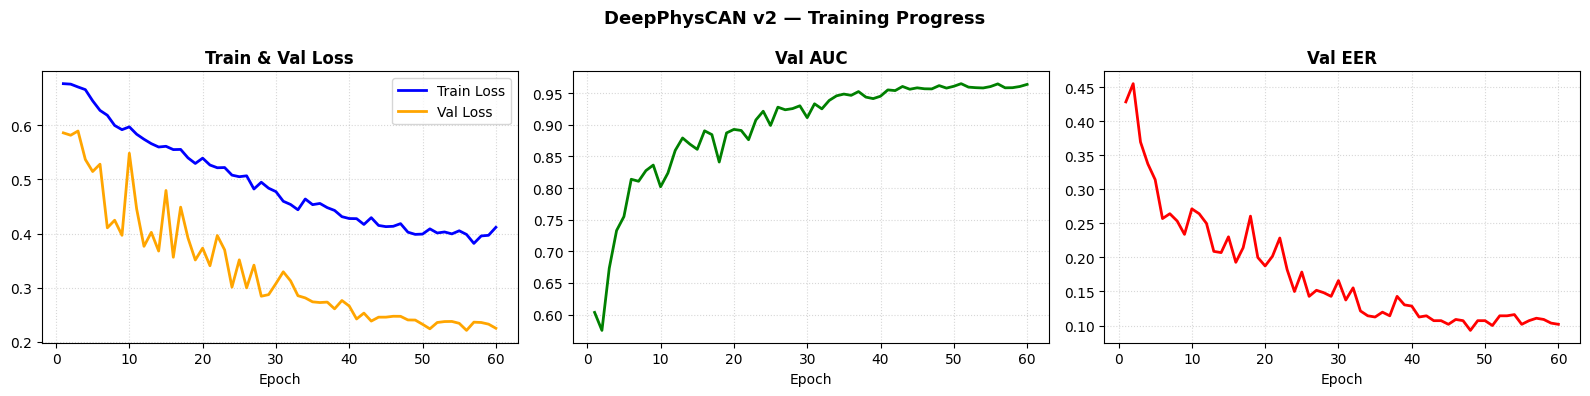

In [9]:
import matplotlib.pyplot as plt

hist_df = pd.read_csv(os.path.join(OUT_DIR, "train_history.csv"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", color="blue", lw=2)
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss", color="orange", lw=2)
axes[0].set_title("Train & Val Loss", fontweight="bold"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, linestyle=":", alpha=0.5)

axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="green", lw=2)
axes[1].set_title("Val AUC", fontweight="bold"); axes[1].set_xlabel("Epoch")
axes[1].grid(True, linestyle=":", alpha=0.5)

axes[2].plot(hist_df["epoch"], hist_df["val_eer"], color="red", lw=2)
axes[2].set_title("Val EER", fontweight="bold"); axes[2].set_xlabel("Epoch")
axes[2].grid(True, linestyle=":", alpha=0.5)

plt.suptitle("DeepPhysCAN v2 — Training Progress", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
plt.show()
